# IC/DAQ Lesson 1: FFT Averaging Exercise

Here we will perform an exercise to extract a signal from a lot of noise. Our signal is sinusoidal and we want to use the FFT to extract it's frequency and amplitude.

In the data folder, there are 100 csv files containing a sinusoidal signal with a lot of noise added. Imagine these as data files from different observations taken at different times. Your task is to extract the frequency and amplitude of the signal contained in these files. The phases are misaligned, so you will need to use the FFT.

Refer to **ICDAQ_Lesson1_Plotting_FFT.ipynb** for a reference on using the fft function we have provided and plotting with matplotlib.

Below, we provide an example of opening one of the csv data files, plotting it, then taking it's FFT.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fft import FFT

## Open a data file

To open one of the csvs we use pandas. The pd.read_csv function returns a DataFrame with a time and amplitude column

In [2]:
x = pd.read_csv('./data/signal0.csv')

In [3]:
x

,time,amplitude
0,0.000,-33.054701
1,0.001,-41.297456
2,0.002,-9.857575
3,0.003,5.265223
4,0.004,-42.322974
...,...,...
995,0.995,21.359007
996,0.996,10.701877
997,0.997,-4.091229
998,0.998,19.730478


To access the time column use:

In [4]:
x.time

0      0.000
1      0.001
2      0.002
3      0.003
4      0.004
       ...  
995    0.995
996    0.996
997    0.997
998    0.998
999    0.999
Name: time, Length: 1000, dtype: float64

Similarly, for the amplitude column

In [5]:
x.amplitude

0     -33.054701
1     -41.297456
2      -9.857575
3       5.265223
4     -42.322974
         ...    
995    21.359007
996    10.701877
997    -4.091229
998    19.730478
999    -7.889294
Name: amplitude, Length: 1000, dtype: float64

We need the sample period for the FFT function. We can extract this with:

In [6]:
T = x.time[1] - x.time[0]

## Plot data and take FFT

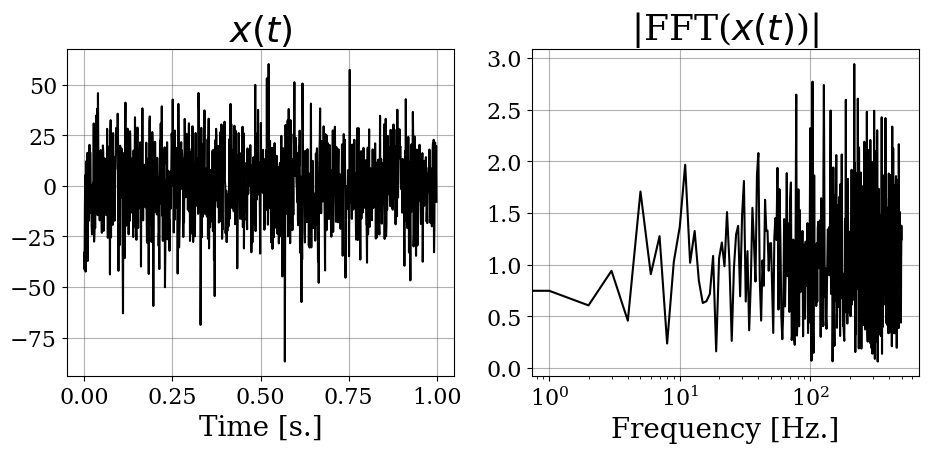

In [7]:
freqs, x_fft = FFT(T, x.amplitude)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t)$',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t)$)|',
    xlabel='Frequency [Hz.]',
    xscale='log'
)

axs[0].plot(x.time, x.amplitude)
axs[1].plot(freqs, x_fft)

## Your code:

Plotting just a single data set shows a very noisy signal, and no clear spike in the FFT. It's up to you to use all of the data provided to find the frequency and amplitude of the signal. Work together, and ask us for help/clarification if you need it. 

Good luck :)

## Solution

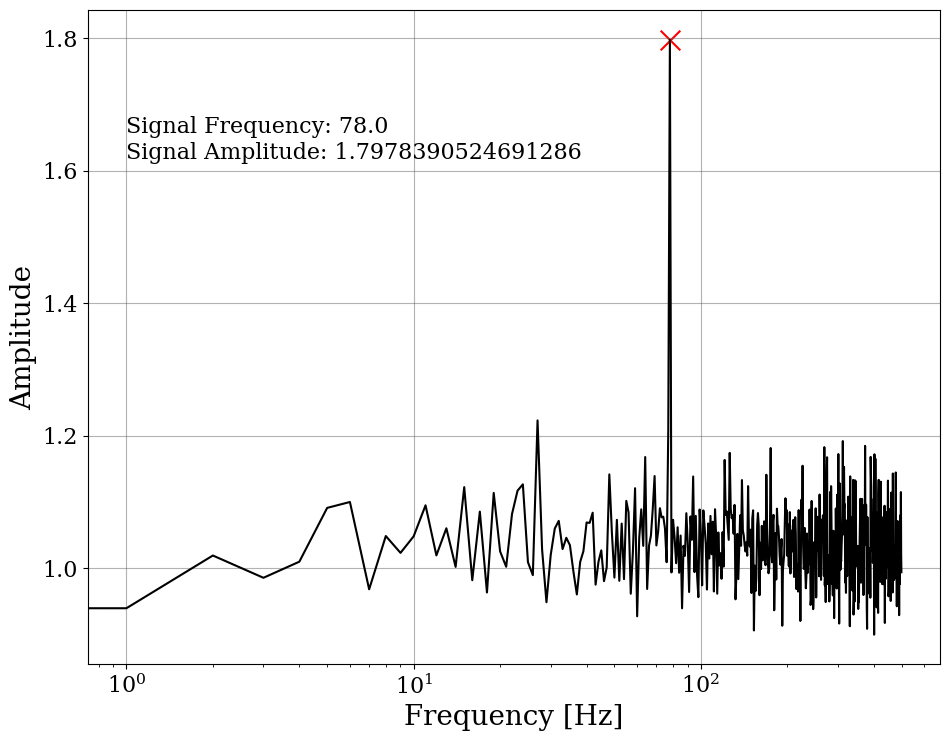

In [8]:
import os

# - get a list of files - #
files = [f for f in os.listdir('./data/') if f.endswith('.csv')]

# - extract the sample period from one file, take a single FFT to get the data size - #
data0 = pd.read_csv(f'./data/{files[0]}')
T = data0.time[1] - data0.time[0]
freqs, fft0 = FFT(T, data0.amplitude)
N = freqs.shape[0]

# - prepare an empty array where we will write our FFTs - #
ffts = np.zeros((len(files), N))

# - loop through the data files, take FFTs, write to the array - #
for i, f in enumerate(files):
    data = pd.read_csv(f'./data/{f}')
    t, x = data.time, data.amplitude
    _, data_fft = FFT(T, x)
    ffts[i, :] = data_fft

# - average all of the FFTs - #
fft_avg = np.mean(ffts, axis=0)

# - find the peak amplitude and frequency - #
peak_index = np.argmax(fft_avg)
frequency = freqs[peak_index]
amplitude = fft_avg[peak_index]

# - plot the result - #
fig, ax = plt.subplots()
ax.set(xlabel='Frequency [Hz]', ylabel='Amplitude', xscale='log')
ax.plot(freqs, fft_avg)
ax.scatter(frequency, amplitude, marker='x', c='r', s=200)
text = ax.text(
    1, 0.9*amplitude, f'Signal Frequency: {frequency}\nSignal Amplitude: {amplitude}',
    size=16
)